### Pie chart

We can clearly observe the major groups from Type_1 feature with more number of belonging Pokemons. Now, let us compare the Attack, Defence, Speed and HP of top 4 major groups for our next analysis. These characteristics define following traits:

Attack: Aggressiveness

Defence: Safeguarding

Speed: Swiftness

HP: Number of hits a Pokemon can receive before it faints

Also, we select only these 4 features out of the complete dataframe to reduce time complexity.

In [2]:
import pandas as pd

df = pd.read_csv('pokemon_alopez247.csv')
       
df_pie = df[['Type_1', 'Attack', 'Defense', 'Speed', 'HP']].copy()
print(df_pie.head())
 


  Type_1  Attack  Defense  Speed  HP
0  Grass      49       49     45  45
1  Grass      62       63     60  60
2  Grass      82       83     80  80
3   Fire      52       43     65  39
4   Fire      64       58     80  58


finding the frequency of each group , and selecting top 4 most frequesnt groups

In [3]:
import numpy as np

values, counts = np.unique(df_pie.iloc[:,0], return_counts=True)

frequent_grp = np.column_stack((values, counts))

frequent_grp = np.array(
    sorted(frequent_grp, key=lambda x: x[1], reverse=True)
)[:4, :]

print(frequent_grp)

[['Water' 105]
 ['Normal' 93]
 ['Grass' 66]
 ['Bug' 63]]


In [4]:
           
df_pie = df_pie.loc[df_pie.loc[:,'Type_1'].str.contains(r'(Water|Normal|Grass|Bug)')]
print(df_pie)
 


     Type_1  Attack  Defense  Speed   HP
0     Grass      49       49     45   45
1     Grass      62       63     60   60
2     Grass      82       83     80   80
6     Water      48       65     43   44
7     Water      63       80     58   59
..      ...     ...      ...    ...  ...
671   Grass      65       48     52   66
672   Grass     100       62     68  123
675  Normal      80       60    102   75
691   Water      53       62     44   50
692   Water      73       88     59   71

[327 rows x 5 columns]


/tmp/ipykernel_8457/2520832553.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_pie = df_pie.loc[df_pie.loc[:,'Type_1'].str.contains(r'(Water|Normal|Grass|Bug)')]



So finally, we are left with the features of the targeted 4 groups. Now, let us find the mean of each group's feature from which we can analyze which group is strong/lack in which area.

In [5]:
           
# Names of the group
type_1_names = frequent_grp[:,0]
print(type_1_names)
# Mean of samples for each feature corresponding to all 4 group 
df_grp = df_pie.groupby('Type_1').mean()
print(df_grp)
 


['Water' 'Normal' 'Grass' 'Bug']
           Attack    Defense      Speed         HP
Type_1                                            
Bug     65.222222  67.698413  60.063492  55.952381
Grass   70.909091  69.363636  59.893939  66.196970
Normal  71.731183  57.795699  69.655914  76.526882
Water   71.047619  70.485714  65.009524  70.866667


The variable df_grp stores the mean value of each feature corresponding to all four groups. Now, let us plot a visualization using pie charts for more clarification.

Text(0.5, 0.98, 'Comparing major features of 4 most frequent Pokemon Group')

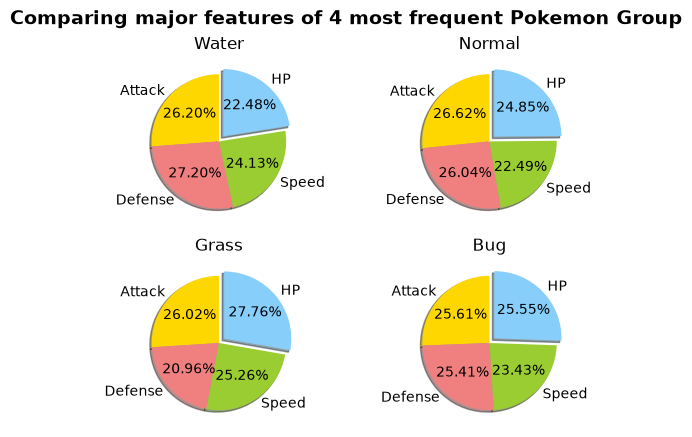

In [7]:
import matplotlib.pyplot as plt
           
names = df_grp.columns
colors = ['gold', 'lightcoral', 
              'yellowgreen', 'lightskyblue']
explode = (0, 0, 0, 0.1)  # takes out only the 4th slice 
fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(nrows=2, ncols=2)
ax = [ax1, ax2, ax3, ax4]
for i in range(0,4):
    percent = df_grp.iloc[i,:]
    ax[i].pie(percent, explode = explode,
            labels = names, colors = colors,
            autopct='%.2f%%',   # display value
            shadow=True,
            startangle=90)
    ax[i].set_aspect('equal')
    ax[i].set_title(type_1_names[i])
plt.suptitle('Comparing major features of 4 most frequent Pokemon Group',
             fontsize = 14,
             fontweight = 'bold')
              


From the chart, we can state the following about the given groups of Pokemon:

Fastest group: Grass Type

Aggressive group: Normal Type

Defensive group: Water Type

Strongest Group: Grass Type